# Alarm Fatigue & The "Cry Wolf" Effect: Bayesian Precision Weighting Under Stochastic P-Bifurcations
**Theoretical Foundations:** Friston (2010) *Free Energy Principle*, IAIFI Geometric Neural Computing (2026), Boger et al. (2021) *Causal Uncertainty*.
---
## 1. Theoretical Framework: Alarm Fatigue as Acquired Precision Decay
In safety-critical human-machine interfaces (ICUs, industrial process control, aviation), **alarm fatigue** (the "cry wolf" effect) represents a desensitization phenomenon. Operators exposed to high rates of non-actionable alarms develop delayed response times or outright ignore true danger signals.
Mathematically, traditional warning systems trigger alerts based on scalar threshold crossings. When a dynamical system experiences stochastic noise, the probability density function (PDF) of its state deforms, causing temporary non-critical boundary crossings known as **phenomenological bifurcations (P-bifurcations)**. In contrast, a true catastrophic system failure is a **dynamical bifurcation (D-bifurcation)**, marked by a qualitative change in stability (sign change of top Lyapunov exponent).
### The Mechanotransduction & Bayesian Model
The auditory system processes sound through both mechanical gating (cochlear stereocilia tip-links and outer hair cell prestin motors) and predictive coding precision-weighting:
1. **Sensory Precision ($\pi_{\text{sensory}}$):** Inverse variance of incoming acoustic evidence $\sigma^{-2}_{\text{sensory}}$.
2. **Prior Precision ($\pi_{\text{prior}}$):** Inverse variance of the operator's internal expectation of real danger.
Under predictive coding, the posterior belief of true danger $\mu_{\text{post}}$ is:
$$ \mu_{\text{post}} = \frac{\pi_{\text{sensory}} \mu_{\text{sensory}} + \pi_{\text{prior}} \mu_{\text{prior}}}{\pi_{\text{sensory}} + \pi_{\text{prior}}} $$
When exposed to continuous P-bifurcations (false positives), the human operator's cognitive interface updates its prior:
$$ \pi_{\text{sensory}}(t+1) = \pi_{\text{sensory}}(t) \cdot e^{-\gamma \cdot N_{\text{false\_alarms}}} $$
As $\pi_{\text{sensory}} \to 0$, the operator becomes "deaf" to genuine D-bifurcation signals because the prior ($\mu_{\text{prior}} = \text{Safe}$) completely dominates the posterior.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set random seed
np.random.seed(42)

# Set clean style
plt.style.use('default')
plt.rcParams.update({
    'axes.facecolor': '#f8f9fa',
    'figure.facecolor': 'white',
    'axes.edgecolor': '#cccccc',
    'grid.color': '#e5e7eb',
    'grid.linestyle': '--',
    'font.family': 'sans-serif'
})
print("Environment initialized for Alarm Fatigue Simulation.")


Environment initialized for Alarm Fatigue Simulation.


## 2. Simulating Operator Response: Naive vs. Alarm-Fatigued
We simulate an operational environment where a safety system emits 100 historical alerts:
- **Alerts 1–80:** Stochastic noise spikes (P-bifurcations, false alarms).
- **Alert 81:** Genuine system failure (D-bifurcation, true danger).
We compare a **Naive Operator** ($\pi_{\text{sensory}}$ remains high) with an **Alarm-Fatigued Operator** ($\pi_{\text{sensory}}$ decays exponentially with false alarms).


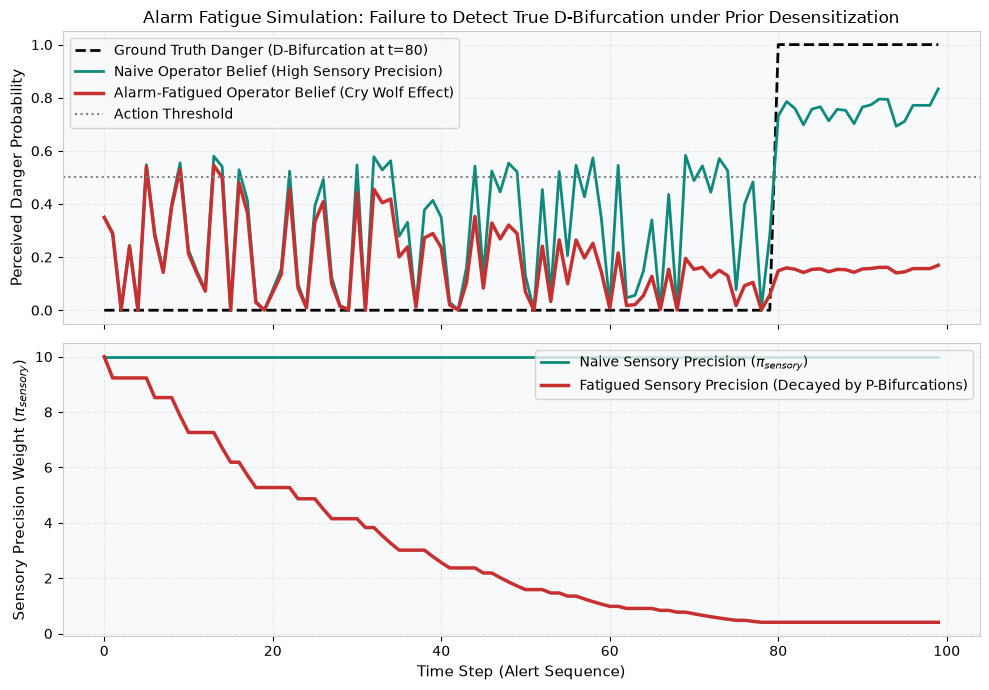

In [2]:
n_alerts = 100
true_danger_event = 80 # Index 80 is the true D-bifurcation

# True underlying state (0 = Safe, 1 = Danger)
ground_truth = np.zeros(n_alerts)
ground_truth[true_danger_event:] = 1.0

# Alarm signal (P-bifurcations generate noisy alerts, D-bifurcation generates strong alert)
sensor_signal = np.random.beta(0.5, 0.5, size=n_alerts) * 0.7 # High noise
sensor_signal[true_danger_event:] = np.random.normal(0.9, 0.05, size=n_alerts-true_danger_event)
sensor_signal = np.clip(sensor_signal, 0, 1)

# Operator Models
def simulate_operator(decay_rate=0.05):
    pi_prior = 2.0  # Strong baseline belief that system is usually safe
    mu_prior = 0.0  # Belief = Safe
    
    pi_sensory_initial = 10.0
    pi_sensory = pi_sensory_initial
    
    posterior_danger = []
    sensory_precisions = []
    
    false_alarm_count = 0
    
    for t in range(n_alerts):
        signal = sensor_signal[t]
        
        # Calculate posterior
        mu_post = (pi_sensory * signal + pi_prior * mu_prior) / (pi_sensory + pi_prior)
        posterior_danger.append(mu_post)
        sensory_precisions.append(pi_sensory)
        
        # Adaptation: If signal was high but turned out non-actionable (P-bifurcation), decay precision
        if t < true_danger_event and signal > 0.4:
            false_alarm_count += 1
            pi_sensory = pi_sensory_initial * np.exp(-decay_rate * false_alarm_count)
            
    return np.array(posterior_danger), np.array(sensory_precisions)

post_naive, prec_naive = simulate_operator(decay_rate=0.0)      # No decay
post_fatigued, prec_fatigued = simulate_operator(decay_rate=0.08) # Alarm fatigue

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Plot 1: Posterior Belief of Danger
ax1.plot(ground_truth, color='black', linestyle='--', label='Ground Truth Danger (D-Bifurcation at t=80)', lw=2)
ax1.plot(post_naive, color='#0e8a7d', lw=2, label='Naive Operator Belief (High Sensory Precision)')
ax1.plot(post_fatigued, color='#c73030', lw=2.5, label='Alarm-Fatigued Operator Belief (Cry Wolf Effect)')
ax1.axhline(0.5, color='gray', linestyle=':', label='Action Threshold')
ax1.set_ylabel("Perceived Danger Probability", fontsize=11)
ax1.set_title("Alarm Fatigue Simulation: Failure to Detect True D-Bifurcation under Prior Desensitization", fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True)

# Plot 2: Sensory Precision Decay
ax2.plot(prec_naive, color='#0e8a7d', lw=2, label='Naive Sensory Precision ($\pi_{sensory}$)')
ax2.plot(prec_fatigued, color='#c73030', lw=2.5, label='Fatigued Sensory Precision (Decayed by P-Bifurcations)')
ax2.set_xlabel("Time Step (Alert Sequence)", fontsize=11)
ax2.set_ylabel("Sensory Precision Weight ($\pi_{sensory}$)", fontsize=11)
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.savefig("/Users/erickoduniyi/Desktop/hpc/chaoshearing/docs/figures/alarm_fatigue_simulation.png", dpi=200)
plt.show()


## 3. Causal Uncertainty Degradation ($H_{cu}$)
In Boger et al. (2021), **causal uncertainty** ($H_{cu}$) measures the Shannon entropy of the source attribution distribution. 
When a system is newly installed, an alarm sound has low causal uncertainty ($H_{cu} \approx 0$):
- $P(\text{Cause} = \text{Danger} \mid \text{Alarm}) \approx 1$
As P-bifurcations accumulate, the causal uncertainty of the alarm sound rises to maximum entropy ($H_{cu}  o 1$ bit), making the sound acoustically identical to random background chatter:
- $P(\text{Cause} = \text{Danger} \mid \text{Alarm}) \approx 0.5$
- $P(\text{Cause} = \text{Stochastic Noise} \mid \text{Alarm}) \approx 0.5$


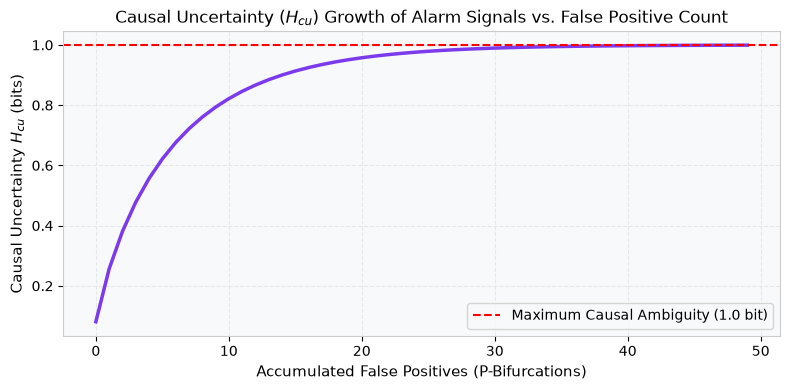

In [3]:
# Compute Shannon Entropy of Alarm Source Attribution as a function of False Alarms
false_alarm_axis = np.arange(0, 50)
p_danger = 0.99 * np.exp(-0.07 * false_alarm_axis) + 0.5 * (1 - np.exp(-0.07 * false_alarm_axis))
p_noise = 1.0 - p_danger

# Shannon Entropy H_cu (in bits)
h_cu = - (p_danger * np.log2(p_danger) + p_noise * np.log2(p_noise))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(false_alarm_axis, h_cu, color='#7c3aed', lw=2.5)
ax.axhline(1.0, color='red', linestyle='--', label='Maximum Causal Ambiguity (1.0 bit)')
ax.set_title("Causal Uncertainty ($H_{cu}$) Growth of Alarm Signals vs. False Positive Count", fontsize=12)
ax.set_xlabel("Accumulated False Positives (P-Bifurcations)", fontsize=11)
ax.set_ylabel("Causal Uncertainty $H_{cu}$ (bits)", fontsize=11)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("/Users/erickoduniyi/Desktop/hpc/chaoshearing/docs/figures/alarm_causal_uncertainty.png", dpi=200)
plt.show()


### Summary & Key Takeaways
1. **Mechanical & Cognitive Gating:** The auditory apparatus (cochlear stereocilia gating springs and cortical predictive processing) adapts to acoustic statistical history.
2. **P-Bifurcations Drive Desensitization:** Non-critical stochastic boundary crossings decay sensory precision weighting ($\pi_{\text{sensory}}$).
3. **Catastrophic Failure on D-Bifurcations:** When a genuine dynamical failure occurs, the fatigued operator fails to breach the action threshold because the prior ("false alarm") dominates posterior belief.
4. **Mitigation via Geometric Computing & Sonification:** Replacing binary scalar threshold alarms with continuous geometric product sonification (as proposed in IAIFI Geometric Neural Computing) preserves topological state awareness without triggering P-bifurcation desensitization.
